# Deep Learning

## Artificial Neural Networks (ANN)
Objective:
  - Bu çalışmada, MNIST el yazısı rakamları içeren veri setini kullanarak yapay sinir ağı (ann) modeli ile sınıflandırma yapmak
  - Model, rakamları (0-9) doğru şekilde tanımlamayı öğrenir ve başarım metrikleri ile değerlendirilir.

Veri seti:
  - mnist, 28x28 piksel boyutlarında, el yazısı ile yazılmış 0-9 arasında toplam 70000 görüntü var
  - 60000 training veri seti, 10000 test veri seti.

Plan/Program:
  1. veri setinin yüklenmesi ve örnek görüntülerin görselleştirilmesi
  2. normalizasyon (0-1 arasına ölçeklendirme)
  3. Etiketlerin one-hot encoding yöntemiyle kategorik hale getirilmesi
  4. yapay sinir ağı mimarisinin oluşturulması
  5. modelin derlenmesi
  6. erken durdurma (early stopping) ve en iyi modelin kaydedilmesi (model check point) callback lerinin tanımlanması
  7. Eğitim ve doğrulama metriklerinin görselleştirilmesi

Kurulumlar:
pip install tensorflow matplotlib

In [2]:
# Import necessary libraries
from tensorflow.keras.datasets import mnist # veri seti
from tensorflow.keras.utils import to_categorical # kategorik verilere çevirme one hot encoding
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential # sirali model, ann ü bunun üzerine inşa et
from tensorflow.keras.layers import Dense # bağlı katman

import matplotlib.pyplot as plt

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


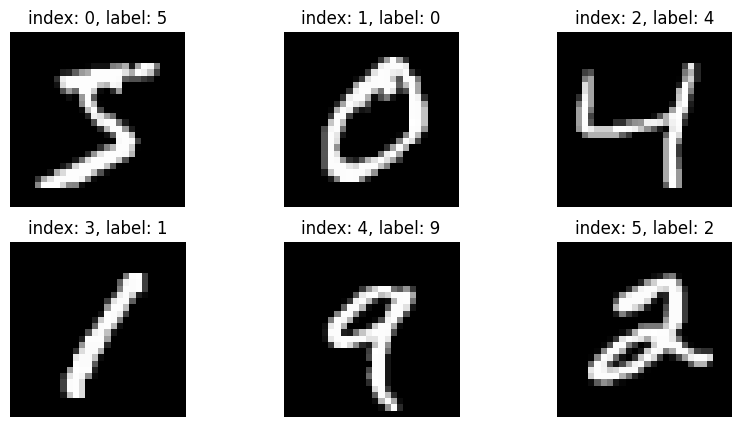

In [3]:
# Split dataset into training and testing sets yükle
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# ilk birkaç örneği görselleştir
plt.figure(figsize = (10,5))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(x_train[i], cmap = "gray")
    plt.title(f"index: {i}, label: {y_train[i]}")
    plt.axis("off")
plt.show()

In [4]:
# Normalize dataset in range 0-255 0-1 aralığına ölçeklendirme
x_train = x_train.reshape((x_train.shape[0], x_train.shape[1]*x_train.shape[2])).astype("float32")/255 # 70000,28,28 -> 70000, 784
x_test = x_test.reshape((x_test.shape[0], x_test.shape[1]*x_test.shape[2])).astype("float32")/255

In [5]:
# Convert labels to categorical, 0,1,2 ...,9 -> on hot encoding
y_train = to_categorical(y_train, 10) # 10 = sınıf sayisi
y_test = to_categorical(y_test, 10)

In [6]:
# Create ANN model
model = Sequential() # base bunun üzerine layer ları ekle


In [10]:
# First layer: 512 cells, relu aktivasyon fonksiyonu, input_size 28*28 = 784
model.add(Dense(512, activation = "relu", input_shape = (28*28,)))

# ikinci katman: 256 cell, tanh aktivasyon fonksiyonu
model.add(Dense(256, activation = "tanh"))

# output layer: 10 tane olmalı çünkü 10 sınıflı bir sınıflandırma problemi çözüyoruz, activation softmax olmalı
# eğer iki sınıflı çözseydik aktivasyon sigmoid
model.add(Dense(10, activation = "softmax"))

In [12]:
# model derlemesi
model.compile(
    optimizer = "adam", # Optimizer algorithm
    loss = "categorical_crossentropy", # Loss function
    metrics = ["accuracy"] # Accuracy
    )

In [14]:
# Callback definition
# Early stopping: stop training if validation (test) loss does not improve
early_stopping = EarlyStopping(
    monitor = "val_loss", # Monitors loss (loss value) on test set
    patience = 5, # Stop if validation loss does not change for 5 epochs
    restore_best_weights = True # Restore weights of the best epoch
    )

In [16]:
# Training: 10 epochs, batch size = 60, validation split = 20%
history = model.fit(
    x_train, y_train, # Training dataset
    epochs = 2, # Model will see the entire dataset 10 times in total
    batch_size = 60, # splits the dataset into batches of 60 ve 1 epoch da 60 ar 60 ar veriyi modele besler
    validation_split = 0.2, # 20% of training data is used for validation
    callbacks = [early_stopping]
)

Epoch 1/2
800/800 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.9570 - loss: 0.1716 - val_accuracy: 0.9584 - val_loss: 0.1654
Epoch 2/2
800/800 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.9710 - loss: 0.1185 - val_accuracy: 0.9662 - val_loss: 0.1393


In [17]:
# model evaluation, gorsellestirme, model save and load
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test acc: {test_acc}, test loss: {test_loss}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9676 - loss: 0.1314
Test acc: 0.9675999879837036, test loss: 0.13136421144008636


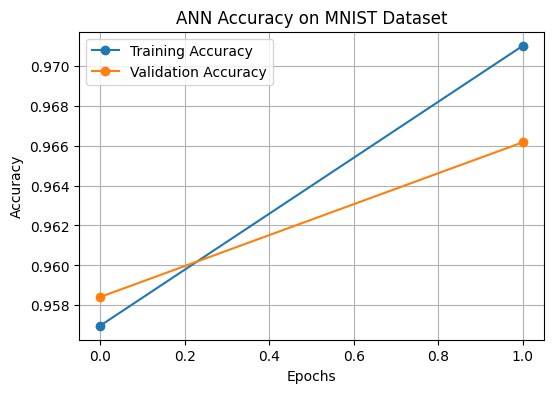

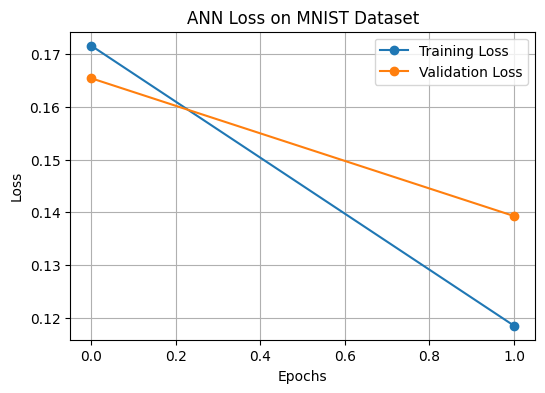

In [19]:
# accuracy training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["accuracy"], marker = "o", label = "Training Accuracy")
plt.plot(history.history["val_accuracy"], marker = "o", label = "Validation Accuracy")
plt.title("ANN Accuracy on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# loss training ve validation
plt.figure(figsize = (6,4))
plt.plot(history.history["loss"], marker = "o", label = "Training Loss")
plt.plot(history.history["val_loss"], marker = "o", label = "Validation Loss")
plt.title("ANN Loss on MNIST Dataset")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## CNN

PROJECT OBJECTIVE
  - Bu proje kapsamında, derin öğrenme tabanlı Evrişimsel Sinir Ağları (CNN)
kullanılarak
  - CIFAR-10 veri seti üzerinde çok sınıflı görüntü sınıflandırma
is solved.

DATASET DESCRIPTION (CIFAR-10)

  - CIFAR-10 dataset is a 10-class image dataset consisting of 32x32 colored images.


Total Image Count  : 60.000
Training Set            : 50.000
Test Seti              : 10.000
Image Size         : 32 x 32 x 3 (RGB)

Classes:
- Airplane
- Automobile
- Bird
- Cat
- Deer
- Dog
- Frog
- Horse
- Ship
- Truck

PROJECT FLOW PLAN

1. Kütüphanelerin içe aktarılması
2. Load CIFAR-10 dataset
3. Data visualization
4. Data preprocessing: Normalization, One-Hot Encoding
5. Data Augmentation
6. Create CNN architecture
7. Modelin derlenmesi (Compile)
8. Train the model (Training)
9. Modelin test edilmesi

In [1]:
# 1. Kütüphanelerin içe aktarılması
# %% veri setini iceriye aktar ve preprocessing: normalizasyon, one-hot encoding
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10 # veri seti
from tensorflow.keras.utils import to_categorical # encoding
from tensorflow.keras.models import Sequential # sirali model
from tensorflow.keras.layers import Conv2D, MaxPooling2D # feature extraction
from tensorflow.keras.layers import Flatten, Dense, Dropout # classification
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator # data augmentation

from sklearn.metrics import classification_report

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


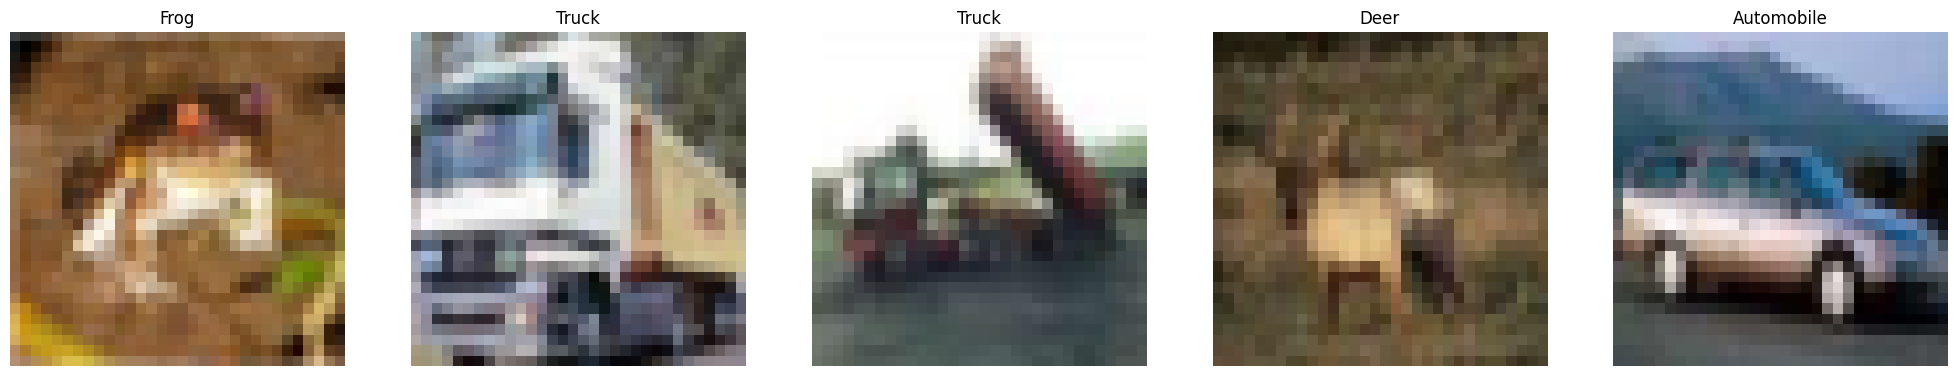

In [2]:
# 2. Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 3. Data visualization
class_labels = ["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse","Ship","Truck"]

# bazi goruntuleri ve etiketlerini gorsellestir
fig, axes = plt.subplots(1, 5, figsize=(25,20))

for i in range(5):
    axes[i].imshow(x_train[i])
    label = class_labels[y_train[i][0]]
    axes[i].set_title(label)
    axes[i].axis("off")

plt.show()

In [3]:
# 4. Data preprocessing: Normalization, One-Hot Encoding
x_train = x_train.astype("float32")/255
x_test = x_test.astype("float32")/255

# one-hot encoding
y_train= to_categorical(y_train, 10) # 10 class var, bu nedenle 10 yaziyoruz
y_test = to_categorical(y_test, 10)

In [4]:
# 5. Data Augmentation
datagen = ImageDataGenerator(
    rotation_range = 20, # 20 dereceye kadar dondurme saglar
    width_shift_range = 0.2, # goruntuyu yatayda %20 kaydirma
    height_shift_range = 0.2, # goruntuyu dikeyde %20 kaydirma
    shear_range = 0.2, # goruntu uzerinde kaydirma
    zoom_range = 0.2, # goruntuye zoom uygulama
    horizontal_flip = True, # goruntuyu yatayda ters cevirme
    fill_mode = "nearest" # bos alanlari doldurmak icin en yakin pixel degerlerini kullan
    )

datagen.fit(x_train) # data augmentation'i egitim verileri uzerinde uygula

In [5]:
# 6. Create CNN architecture
model = Sequential()

# Feature Extraction: CONV => RELU => CONV => RELU => POOL => DROPOUT
model.add(Conv2D(32, (3,3), padding = "same", activation = "relu", input_shape = x_train.shape[1:]))
model.add(Conv2D(32, (3,3), activation = "relu"))
model.add(MaxPooling2D(pool_size = (2,2)))
model.add(Dropout(0.25)) # baglantilarin %25'ini rasgele olarak kapat

# Feature Extraction: CONV => RELU => CONV => RELU => POOL => DROPOUT
model.add(Conv2D(64, (3,3), padding = "same", activation="relu"))
model.add(Conv2D(62, (3,3), activation = "relu"))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Classification: FLATTEN, DENSE, RELU, DROPOUT, DENSE (OUTPUT LAYER)
model.add(Flatten()) # vektor olustur
model.add(Dense(512, activation = "relu"))
model.add(Dropout(0.5))
model.add(Dense(10, activation = "softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# 7. Modelin derlenmesi (Compile)
model.compile(optimizer = RMSprop(learning_rate = 0.0001, decay= 1e-6),
              loss = "categorical_crossentropy",
                metrics = ["accuracy"])

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


In [7]:
# 8. Train the model (Training)
history = model.fit(datagen.flow(x_train, y_train, batch_size = 512), # data augmentation uygulanmis veri akisi
          epochs=1, # egitim donem sayisi
          validation_data = (x_test, y_test) # dogrulama seti
          )

98/98 ━━━━━━━━━━━━━━━━━━━━ 54s 451ms/step - accuracy: 0.1693 - loss: 2.1993 - val_accuracy: 0.2479 - val_loss: 2.0420


In [8]:
# 9. Modelin test edilmesi

# modelin test seti uzerinden tahminini yap
y_pred = model.predict(x_test) # y_pred = [0, 1] mesela 0.8 cikarsa %80 olma olasiligi olarak tariflenebilir.
y_pred_class = np.argmax(y_pred, axis=1) # Prediction edilen siniflari al
y_true = np.argmax(y_test, axis = 1)

# classification report hesapla
report = classification_report(y_true, y_pred_class, target_names=class_labels)
print(report)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
              precision    recall  f1-score   support

    Airplane       0.25      0.68      0.36      1000
  Automobile       0.32      0.09      0.14      1000
        Bird       0.17      0.12      0.14      1000
         Cat       0.18      0.02      0.03      1000
        Deer       0.20      0.03      0.05      1000
         Dog       0.24      0.15      0.18      1000
        Frog       0.25      0.69      0.37      1000
       Horse       0.27      0.18      0.22      1000
        Ship       0.29      0.23      0.26      1000
       Truck       0.24      0.29      0.27      1000

    accuracy                           0.25     10000
   macro avg       0.24      0.25      0.20     10000
weighted avg       0.24      0.25      0.20     10000



## RNN

Objective:
  - perform sentiment analysis using RNN
  - classification problem: create restaurant reviews dataset, label: positive (1) / negative (0)

Steps:
  1. Import necessary libraries
  2. create restaurant reviews dataset
  3. text preprocessing (preprocessing): tokenization, padding, label encoding (etiket kodlama), train test split
  4. embedding: create numerical vectors with word2vec
  5. rnn modeli oluşturma (embedding + simpleRNN + Dense Layer)
  6. compile and train the RNN model
  7. evaluate the model on the test dataset


In [10]:
# pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 69.8 MB/s eta 0:00:00


In [11]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential # base model
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer # tokenization process

from tensorflow.keras.utils import pad_sequences
from gensim.models import Word2Vec # embedding

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [12]:
# 2. veri seti oluşturma
reviews_data = {
    "text": [
        # ---------- POSITIVE (50) ----------
        "The food was absolutely delicious and perfectly cooked.",
        "Loved the cozy atmosphere and friendly staff.",
        "The pasta tasted fresh and homemade.",
        "Excellent service and wonderful presentation.",
        "Beautiful interior design, I felt very comfortable.",
        "Desserts were heavenly, especially the chocolate mousse.",
        "Very polite staff and quick service.",
        "The burger was juicy and full of flavor.",
        "Great wine selection and relaxing vibe.",
        "The sushi was fresh and beautifully presented.",
        "Amazing experience, we’ll definitely come again.",
        "Loved how clean and elegant the place was.",
        "The seafood platter was generous and tasty.",
        "Everything we tried was top-notch.",
        "Perfect spot for a romantic dinner.",
        "The pizza crust was crispy and flavorful.",
        "Really nice view from the terrace.",
        "Staff was attentive and professional.",
        "Loved the vegan options on the menu.",
        "Fantastic service and quick delivery.",
        "Great cocktails and friendly bartender.",
        "Everything tasted fresh and perfectly seasoned.",
        "Loved every dish we ordered.",
        "The fish was tender and flavorful.",
        "Best steak I’ve had in years!",
        "Absolutely loved the breakfast buffet, everything was fresh and hot.",
        "The waiter was so kind and helpful throughout our meal.",
        "Amazing flavors! The chef really knows what he’s doing.",
        "The ambiance was peaceful, perfect for a family dinner.",
        "Portions were generous and worth the price.",
        "The risotto was creamy and full of flavor.",
        "Loved the live music performance during dinner.",
        "Everything came out on time and nicely plated.",
        "The waitress remembered our names, great personal touch!",
        "The grilled chicken was juicy and well seasoned.",
        "They offered free dessert for our anniversary, so thoughtful!",
        "The restaurant smelled wonderful when we walked in.",
        "The lemonade was freshly made and refreshing.",
        "Clean tables, fast service, and friendly smiles — perfect!",
        "My kids loved the mac and cheese, will definitely return.",
        "The soup was flavorful and comforting.",
        "I appreciated the variety of vegetarian dishes.",
        "Excellent value for money, highly recommended.",
        "The chef customized my order exactly as I asked.",
        "Loved the open terrace view, so relaxing.",
        "Waiters were cheerful and attentive.",
        "Everything was hot and served just right.",
        "The chocolate lava cake was divine!",
        "Beautiful plating and attention to detail.",
        "They even offered complimentary coffee at the end.",

        # ---------- NEGATIVE (50) ----------
        "The waiter was rude and seemed annoyed the whole time.",
        "Our order was wrong and took forever to arrive.",
        "Tables were dirty and the floor was sticky.",
        "The steak was dry and overcooked.",
        "Terrible experience, I won’t be coming back.",
        "The soup was cold and bland.",
        "Overpriced for the small portions they serve.",
        "The music was too loud and annoying.",
        "Waited 45 minutes just to get a salad.",
        "They forgot our drinks twice.",
        "The bread was stale and hard.",
        "The waiter ignored us for most of the night.",
        "They messed up the bill and charged extra.",
        "The chairs were uncomfortable and wobbly.",
        "Worst dining experience ever.",
        "Our food arrived cold and unappetizing.",
        "The salad had no dressing and was wilted.",
        "The restroom was disgusting.",
        "Too expensive for what you get.",
        "Found a hair in my soup.",
        "The fries were soggy and undercooked.",
        "The air conditioning wasn’t working, it was hot.",
        "Too crowded and noisy to enjoy the meal.",
        "They ran out of half the menu.",
        "They charged for water, unbelievable.",
        "The food took over an hour to arrive.",
        "Our table was right next to the restroom, awful smell.",
        "The staff seemed totally unorganized.",
        "My steak was raw in the middle.",
        "The drinks were watered down and tasteless.",
        "Too dark inside, couldn’t even read the menu.",
        "They served cold fries and didn’t replace them.",
        "Music was blasting, couldn’t hear anyone at the table.",
        "The menu looked fancy but the food was disappointing.",
        "They forgot my order completely.",
        "Waited 20 minutes just to get water.",
        "The pasta sauce was way too salty.",
        "Hostess was rude and dismissive.",
        "They seated us near a drafty door, freezing!",
        "No parking available nearby, huge inconvenience.",
        "The chicken was rubbery and bland.",
        "Our dessert never arrived, even after reminding twice.",
        "Service charge added without telling us.",
        "They ran out of napkins halfway through dinner.",
        "Tables were sticky and unclean.",
        "The meat smelled strange, not fresh at all.",
        "Our reservation wasn’t found in the system.",
        "Too expensive for such poor quality food.",
        "They spilled soup on the table and didn’t apologize.",
        "Cold food, bad service, not coming again."
    ],
    "labels": [
        # 50 positive
        *["positive"] * 50,
        # 50 negative
        *["negative"] * 50
    ]
}


In [15]:
# text preprocessing
# tokenization
# dataframe e çevir
df = pd.DataFrame(reviews_data)
print(df.head())
tokenizer = Tokenizer() # converts words to numerical indexes
tokenizer.fit_on_texts(df["text"]) # creates word vocabulary
text_sequences = tokenizer.texts_to_sequences(df["text"]) # converts reviews to number sequences
word_index = tokenizer.word_index
print(word_index)

                                                text    labels
0  The food was absolutely delicious and perfectl...  positive
1      Loved the cozy atmosphere and friendly staff.  positive
2               The pasta tasted fresh and homemade.  positive
3      Excellent service and wonderful presentation.  positive
4  Beautiful interior design, I felt very comfort...  positive
{'the': 1, 'and': 2, 'was': 3, 'they': 4, 'for': 5, 'our': 6, 'loved': 7, 'were': 8, 'to': 9, 'food': 10, 'service': 11, 'of': 12, 'too': 13, 'fresh': 14, 'everything': 15, 'a': 16, 'in': 17, 'my': 18, 'staff': 19, 'i': 20, 'dinner': 21, 'menu': 22, 'soup': 23, 'cold': 24, 'friendly': 25, 'great': 26, 'experience': 27, 'we': 28, 'perfect': 29, 'flavorful': 30, 'on': 31, 'steak': 32, 'hot': 33, 'waiter': 34, 'so': 35, 'music': 36, 'out': 37, 'tables': 38, 'order': 39, 'just': 40, 'even': 41, 'at': 42, 'get': 43, 'us': 44, 'table': 45, 'absolutely': 46, 'perfectly': 47, 'pasta': 48, 'tasted': 49, 'excellent': 50, 'wo

In [16]:
# padding
"""
max padding length = 3

    - evaluate the model on the test dataset:
        - test seti üzerinden
        - modelin değerlendirilmesi 0
    - user test
        - user test 0
"""
max_sequence_len = max(len(seq) for seq in text_sequences)
print(max_sequence_len)
X = pad_sequences(text_sequences, maxlen=max_sequence_len) # pad all sentences to the same length
print(f"Input data shape: {X.shape}") # (100, 10)

10
Giriş verisinini boyutu: (100, 10)


In [18]:
# label encoding
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["labels"]) # positive = 1, negative = 0

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# 4. embedding
sentences = [text.split() for text in df["text"]]
# train word2vec model
embedding_dim = 50
word2vec_model = Word2Vec(sentences, vector_size=embedding_dim, window=5, min_count=1)

# embedding matrisi
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dim))
for word, idx in word_index.items():
    if word in word2vec_model.wv:
        embedding_matrix[idx] = word2vec_model.wv[word]
print(f"embedding matris: {embedding_matrix}")

embedding matris: [[ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.01542055 -0.01904649 -0.00063714 ... -0.00532242 -0.01879257
   0.00912681]
 [-0.00135636  0.00037204  0.00984608 ...  0.01858133  0.01012342
   0.01841119]
 ...
 [-0.00235903 -0.00474097 -0.00369994 ... -0.00143787  0.00182739
   0.01360518]
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [-0.00547641  0.00019958  0.00402067 ... -0.01983353 -0.01956106
   0.002188  ]]


In [20]:

# 5. Create RNN model
model = Sequential()

# modele embedding katmanı eklenmesi
model.add(Embedding(
    input_dim = len(word_index) + 1, # total word count + 1 (i.e. zero value)
    output_dim = embedding_dim, # embedding boyutu (50)
    weights = [embedding_matrix], # pretrained word2vec embedding matrix
    input_length = max_sequence_len, # max sentence length (10)
    trainable = False # embedding weights will remain fixed
    )
)

# rnn layer: units = hidden layer count, return_sequences = returns only the final output
model.add(SimpleRNN(units = 50, return_sequences = False))

# output layer
model.add(Dense(1, activation = "sigmoid")) # sigmoid for binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
# Compile
model.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy"])


In [22]:
# 6. training
model.fit(
    X_train, y_train,
    epochs = 10, # number of epochs
    batch_size = 2, # mini batch size
    validation_data = (X_test, y_test) # validation with test dataset
)

Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.4875 - loss: 0.7039 - val_accuracy: 0.4000 - val_loss: 0.7007
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6000 - loss: 0.6875 - val_accuracy: 0.6000 - val_loss: 0.6994
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6625 - loss: 0.6699 - val_accuracy: 0.4500 - val_loss: 0.7052
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7250 - loss: 0.6417 - val_accuracy: 0.5500 - val_loss: 0.7006
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7250 - loss: 0.5826 - val_accuracy: 0.5500 - val_loss: 0.7894
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7375 - loss: 0.5478 - val_accuracy: 0.4500 - val_loss: 0.8407
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7875 - loss: 0.4747 - val_accuracy: 0.6500 - val_loss: 0.6397
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9250 - loss: 0.3820 - val_accuracy: 0.6500 - val_los

In [23]:
# 7. evaluation with test dataset
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test loss: {test_loss}")
print(f"Test acc: {test_acc}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 924ms/step - accuracy: 0.5000 - loss: 0.9963
Test loss: 0.9962506294250488
Test acc: 0.5
